**Model to Predict teen depression using behavioral and lifestyle factors using KNN and Naive Bayes.**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv(r"/content/Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
df['depression_label'].value_counts()

,count
depression_label,
0,1169
1,31


In [ ]:
# Highly imbalanced, so we need to balance it using smote

In [ ]:
df.shape

(1200, 13)

In [ ]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [ ]:
df.sample(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1016,18,female,2.3,Instagram,8.7,0.6,2.76,1.9,high,4,8,7,0
560,16,male,2.7,Both,7.2,0.6,3.98,1.7,low,6,1,5,0
1070,15,female,7.3,Both,5.7,2.9,3.48,1.8,medium,2,7,8,0
698,15,male,6.7,Both,4.3,1.8,3.69,0.7,high,2,8,7,0
1133,15,female,1.1,Instagram,9.0,1.2,2.90,1.8,medium,5,10,2,0
174,15,male,1.9,TikTok,5.8,2.3,2.47,0.3,high,10,9,4,0
731,18,male,1.0,Instagram,7.1,0.8,2.47,1.9,high,4,2,4,0
1147,19,male,5.3,Instagram,4.7,2.8,2.82,0.3,high,1,9,6,0
269,19,male,1.8,Instagram,6.5,2.6,2.75,1.7,high,7,6,1,0
419,15,male,5.1,Instagram,7.4,0.7,2.64,0.2,medium,5,8,1,0


In [ ]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
df.dtypes


,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.isnull().sum()  # No null values

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
df.duplicated().value_counts()

,count
False,1200


In [ ]:
df['gender'].value_counts()

,count
gender,
male,615
female,585


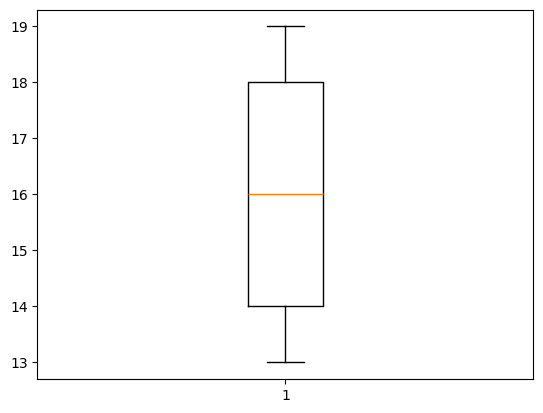

In [ ]:
# check for outliers using boxplot
import matplotlib.pyplot as plt
plt.boxplot(df["age"])
plt.show()


In [ ]:
# Label encoding of categorical columns to be performed for gender,platform_usage & social_interaction_level

In [ ]:
from sklearn.preprocessing import LabelEncoder

LE=LabelEncoder()
df['gender']=LE.fit_transform(df['gender'])
df['platform_usage']=LE.fit_transform(df['platform_usage'])
df['social_interaction_level']=LE.fit_transform(df['social_interaction_level'])

In [ ]:
df.dtypes

,0
age,int64
gender,int64
daily_social_media_hours,float64
platform_usage,int64
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,int64
stress_level,int64


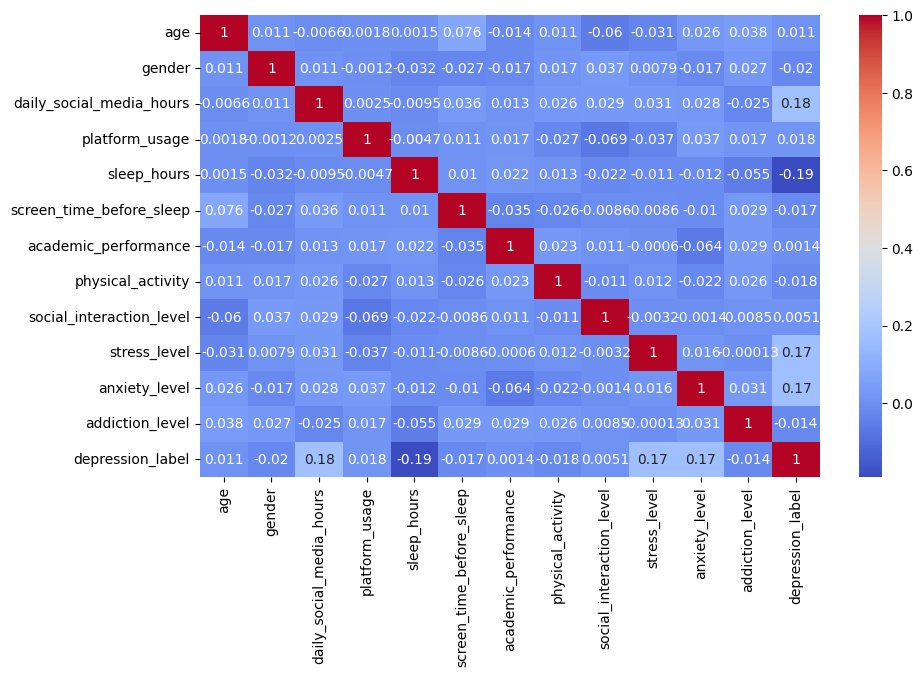

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

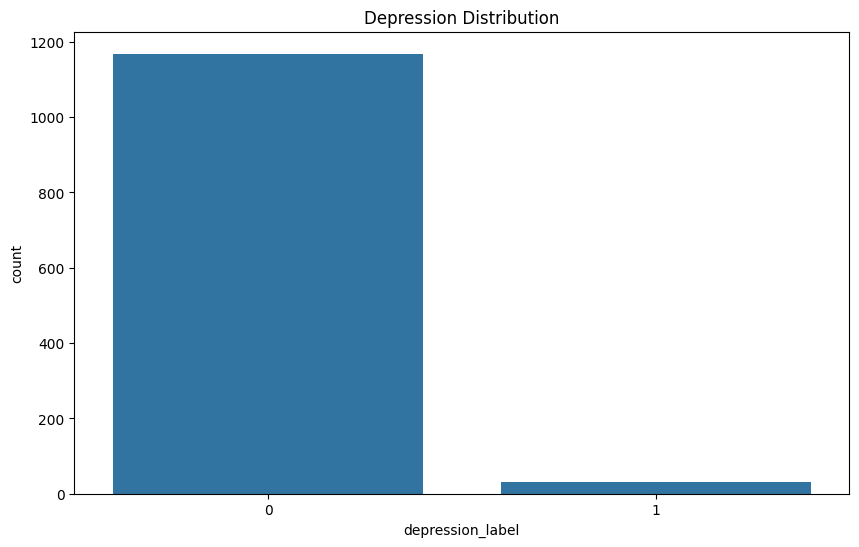

In [ ]:
# depression distribution
plt.figure(figsize=(10,6))
sns.countplot(x="depression_label",data=df)
plt.title('Depression Distribution')
plt.show()

In [ ]:
# The dataset is highly imbalanced, with non-depressed teens significantly outnumbering depressed teens. Therefore, SMOTE was applied to address imbalance.

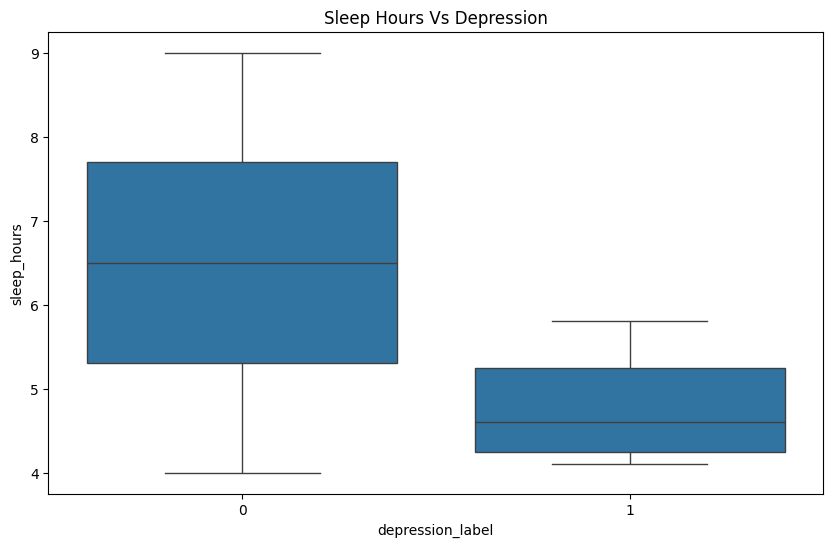

In [ ]:
# Sleep hours Vs Depression
plt.figure(figsize=(10,6))
sns.boxplot(x='depression_label',y='sleep_hours',data=df)
plt.title("Sleep Hours Vs Depression")
plt.show()

In [ ]:
# Teens with dression sleep around: 4 to 5.5 hours [mean=6.5 hrs]
# Teens without dression sleep around: 5 to 8 hours [mean=4.5 hrs]
# Teens with depression tend to sleep fewer hours compared to teens without depression.

In [ ]:
# Observation: Teens diagnosed with depression tend to have lower sleep duration compared to non-depressed teens. The median sleep duration for depressed teens is noticeably lower, suggesting sleep hours may be an
# important behavioral factor influencing teen depression.

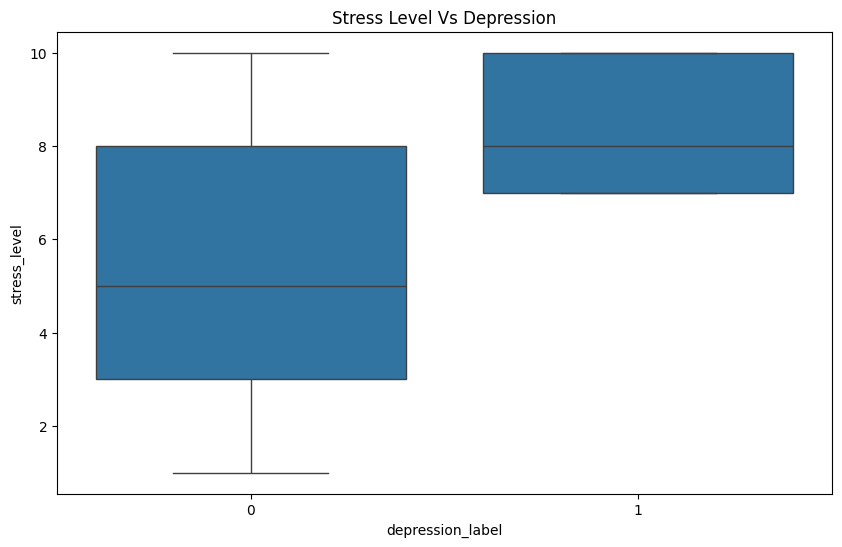

In [ ]:
# Stress Level vs Depression
plt.figure(figsize=(10,6))

sns.boxplot(x='depression_label',y='stress_level',data=df)
plt.title('Stress Level Vs Depression')
plt.show()

In [ ]:
# Teens with depression is having higher stree levels with median value 8
# Teens without depression is having a lower stress level with med value of 5

# Why the depression box (1) has no whiskers on both sides?

# Good observation 👏

# This happens because of your data distribution.

# A boxplot has:

# Box → middle 50% of data (Q1 to Q3)
# Middle line → median
# Whiskers → minimum and maximum values within range

# In your depression group (1):

# It looks like:

# Minimum ≈ 7
# Q1 ≈ 7
# Median ≈ 8
# Q3 ≈ 10
# Maximum ≈ 10

# So:

# Lower whisker disappears because minimum = Q1
# Upper whisker disappears because maximum = Q3

# That means there are many repeated values and very little spread outside the box.

In [ ]:
# Anxiety Level vs Depression

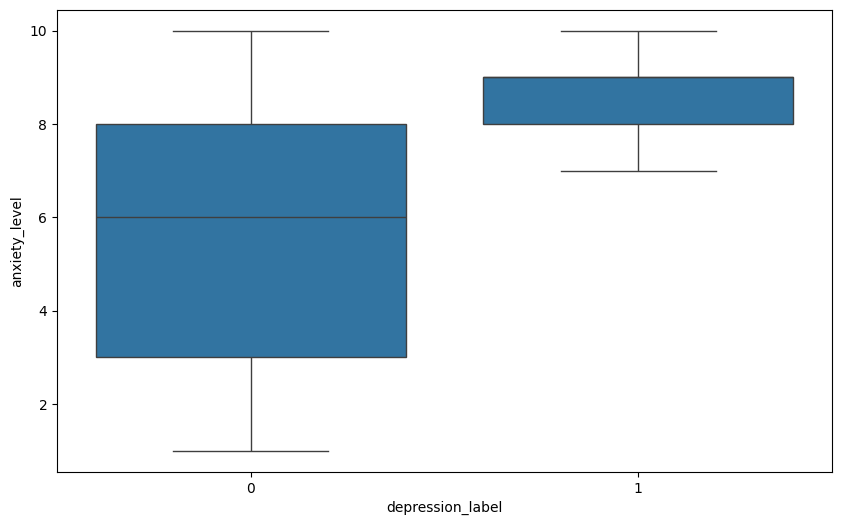

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='depression_label',y= 'anxiety_level',data=df)
plt.show()

In [ ]:
# Teens with depression show higher anxiety levels compared to non-depressed Teens. Anxiety scores for depressed Teens are concentrated at higher values (mostly 8–10),
# indicating a stronger relationship between anxiety and depression

In [ ]:
df[df['depression_label']==1]['anxiety_level'].describe()

,anxiety_level
count,31.000000
mean,8.612903
std,1.054433
min,7.000000
25%,8.000000
50%,9.000000
75%,9.000000
max,10.000000


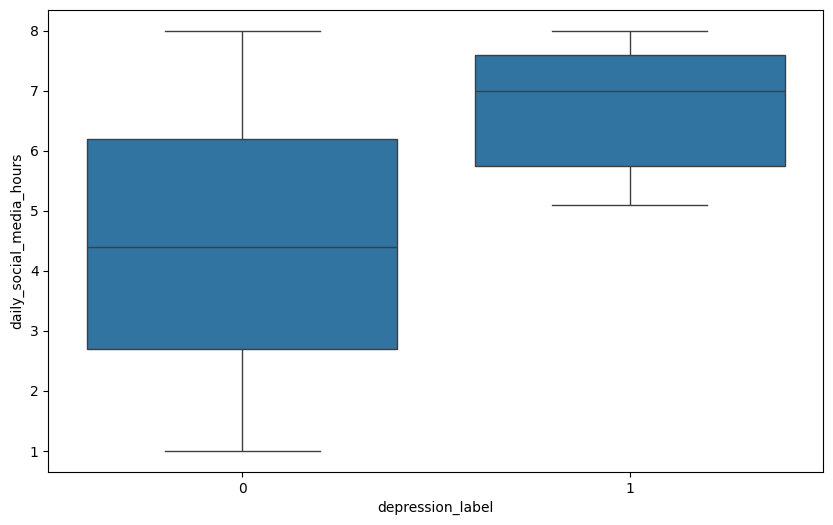

In [ ]:
# Social Media Usage vs Depression
plt.figure(figsize=(10,6))
sns.boxplot(x='depression_label', y='daily_social_media_hours',data=df)
plt.show()

In [ ]:
# The observation is that teens with depressions seems to spend more hrs on social media (6 to 8 hrs) than teens without depression(3-6 hrs)

In [ ]:
# Train_Test_Split

In [ ]:
x=df[['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level']]

x

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,1,6.6,2.0,2.76,1.0,1,3,4,4
1196,16,1,2.3,0,8.0,1.9,2.12,0.4,0,7,4,4
1197,14,0,1.7,0,8.7,0.7,3.98,0.8,0,1,1,1
1198,15,1,3.9,0,8.5,2.1,3.19,0.6,0,7,9,9


In [ ]:
y=df['depression_label']
y

,depression_label
0,0
1,0
2,0
3,0
4,0
...,...
1195,0
1196,0
1197,0
1198,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [ ]:
# SMOTE---> to make the dataset balanced

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=1)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)


In [ ]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

depression_label
0    818
1     22
Name: count, dtype: int64
depression_label
0    818
1    818
Name: count, dtype: int64


In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train_smote=ss.fit_transform(x_train_smote)
x_test=ss.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kcl=KNeighborsClassifier(n_neighbors=5)
# to train model
kcl.fit(x_train_smote,y_train_smote)

KNeighborsClassifier()

In [ ]:
y_pred=kcl.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

0.9694444444444444
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       351
           1       0.25      0.11      0.15         9

    accuracy                           0.97       360
   macro avg       0.61      0.55      0.57       360
weighted avg       0.96      0.97      0.96       360



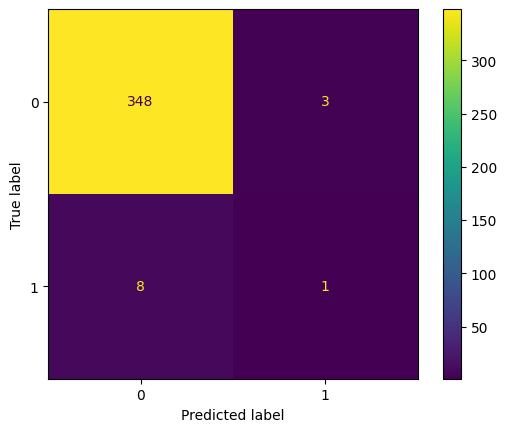

In [ ]:
# test Accuracy

from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [ ]:
#  Using NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
bmodel=nb.fit(x_train_smote,y_train_smote)

In [ ]:
y_pred=bmodel.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

0.9694444444444444
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       351
           1       0.25      0.11      0.15         9

    accuracy                           0.97       360
   macro avg       0.61      0.55      0.57       360
weighted avg       0.96      0.97      0.96       360



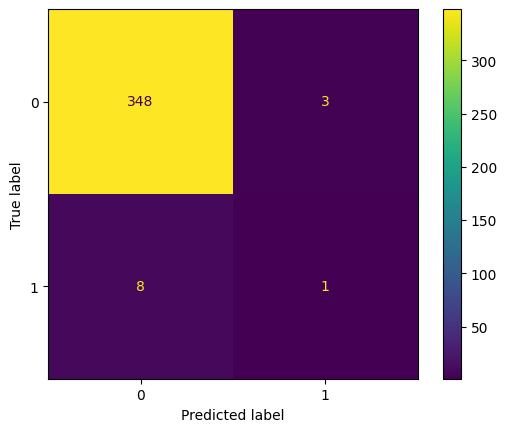

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))